# Formula Visualization

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

We first define the galaxy model in Agama. This consists of:

1. A spheroidal dark matter halo potential. We will use the generalized NFW profile, which has a density profile given by:
$$\rho(r) = \frac{\rho_0}{(r/r_s)^\gamma (1 + (r/r_s)^\alpha)^{(\beta - \gamma)/\alpha}}$$

where $\rho_0$ is the density normalization, $r_s$ is the scale radius, $\beta$ is the outer slope, $\gamma$ is the inner slope, and $\alpha$ controls the transition between the inner and outer slopes. We will fix $\alpha=1$ and $\beta=3$, and vary the rest.

2. A stellar core. We will use a Plummer sphere, which has a density profile given by:
$$\nu_\star(r) = \frac{3M}{4\pi r_\star^3} \left(1 + \frac{r^2}{r_\star^2}\right)^{-5/2}$$

3. An isotropic distribution function

In [ ]:
def gnfw_density()

In [ ]:
gamma = np.linspace(-1, 2, 1000)
rho_0 = np.linspace(5, 8, 1000)



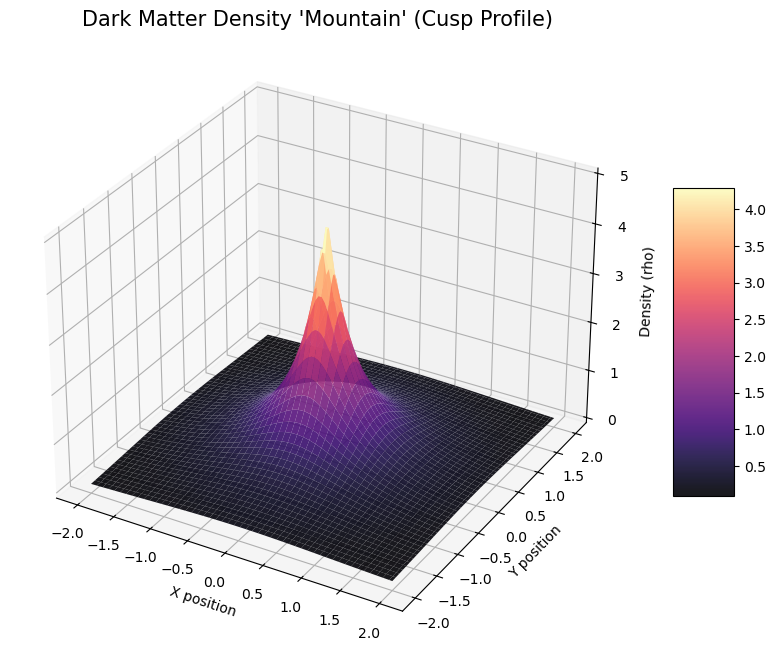

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Define the GNFW Function from your paper
def gnfw_density(x, y, rho0=1, rs=1, gamma=1):
    r = np.sqrt(x**2 + y**2) + 1e-9 # Avoid division by zero
    # Formula from Eq 1:
    density = rho0 * (r/rs)**(-gamma) * (1 + r/rs)**(-(3-gamma))
    return density

# 2. Create a grid (X, Y)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

# 3. Calculate Z (Density) for a CUSP (gamma=1)
Z_cusp = gnfw_density(X, Y, gamma=0, rho0=5)

# 4. Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# surface plot
surf = ax.plot_surface(X, Y, Z_cusp, cmap='magma', edgecolor='none', alpha=0.9)

# Labels
ax.set_title("Dark Matter Density 'Mountain' (Cusp Profile)", fontsize=15)
ax.set_zlim(0, 5) # Clip the infinite spike for visibility
ax.set_xlabel('X position')
ax.set_ylabel('Y position')
ax.set_zlabel('Density (rho)')

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()

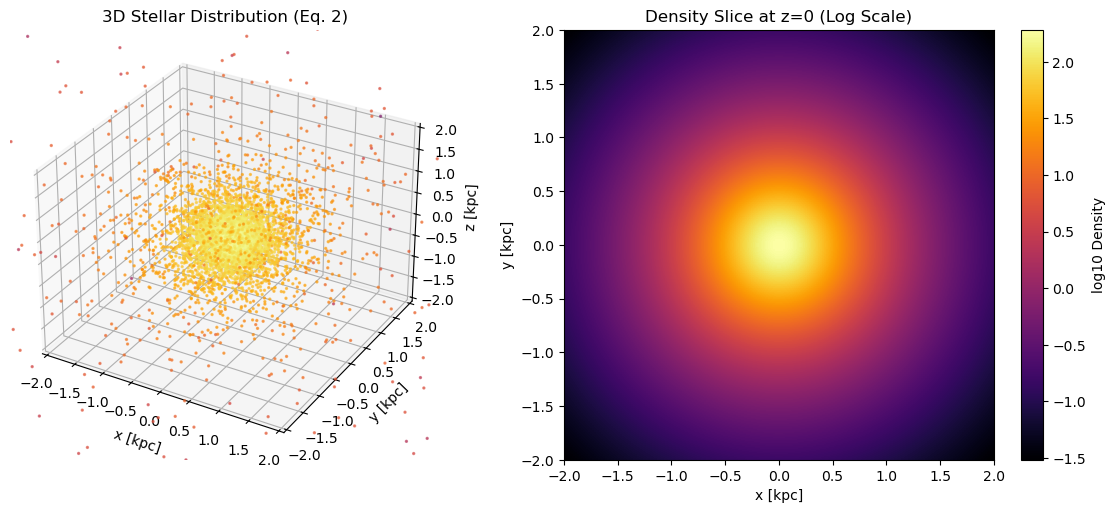

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plummer_3d_density(r, L, r_star):
    return (3 * L / (4 * np.pi * r_star**3)) * (1 + (r**2 / r_star**2))**(-2.5)

# Parameters
L = 100
r_star = 0.5  # kpc
n_points = 5000

# 1. Generate random 3D positions
# To truly represent the 3D density, we sample points 
# This mimics how stars are distributed in the dwarf galaxy
phi = np.random.uniform(0, 2 * np.pi, n_points)
costheta = np.random.uniform(-1, 1, n_points)
u = np.random.uniform(0, 1, n_points)

theta = np.arccos(costheta)
# Sampling radius according to the Plummer cumulative distribution function
r = r_star / np.sqrt(u**(-2/3) - 1)

# Convert to Cartesian coordinates
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

# 2. Calculate density at each point for coloring
densities = plummer_3d_density(r, L, r_star)

# 3. Plotting
fig = plt.figure(figsize=(12, 5))

# --- Left Plot: 3D Point Cloud ---
ax1 = fig.add_subplot(121, projection='3d')
scatter = ax1.scatter(x, y, z, c=np.log10(densities), cmap='inferno', s=2, alpha=0.6)
ax1.set_title("3D Stellar Distribution (Eq. 2)")
ax1.set_xlim([-2, 2]); ax1.set_ylim([-2, 2]); ax1.set_zlim([-2, 2])
ax1.set_xlabel('x [kpc]'); ax1.set_ylabel('y [kpc]'); ax1.set_zlabel('z [kpc]')

# --- Right Plot: 2D Cross-section Heatmap ---
ax2 = fig.add_subplot(122)
grid_size = np.linspace(-2, 2, 200)
X, Y = np.meshgrid(grid_size, grid_size)
R = np.sqrt(X**2 + Y**2)
Z_dens = plummer_3d_density(R, L, r_star)

im = ax2.imshow(np.log10(Z_dens), extent=[-2, 2, -2, 2], cmap='inferno', origin='lower')
ax2.set_title("Density Slice at z=0 (Log Scale)")
ax2.set_xlabel('x [kpc]')
ax2.set_ylabel('y [kpc]')
plt.colorbar(im, label='log10 Density')

plt.tight_layout()
plt.show()

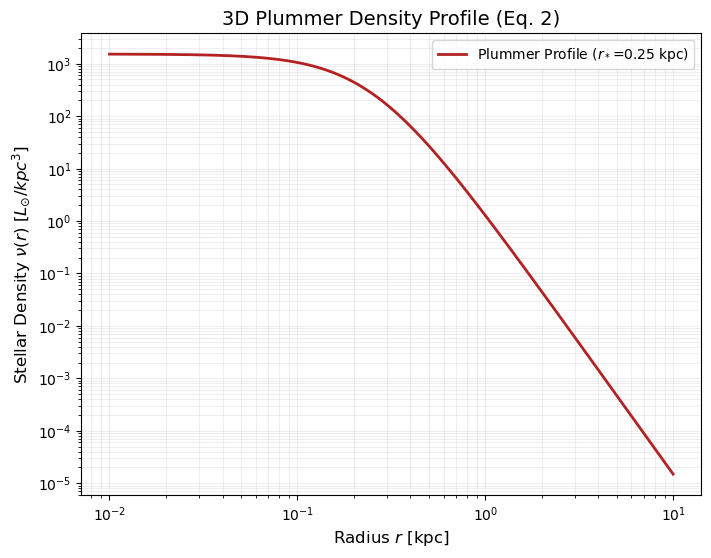

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plummer_3d_density(r, L, r_star):
    """
    Implementation of Equation (2):
    nu(r) = (3L / 4 * pi * r_star^3) * (1 + r^2 / r_star^2)^(-5/2)
    """
    term1 = (3 * L) / (4 * np.pi * r_star**3)
    term2 = (1 + (r**2 / r_star**2))**(-2.5)
    return term1 * term2

# Parameters from the paper (e.g., Figure 6 caption)
L_total = 100        # Total luminosity (L_sun)
r_scale = 0.25      # Scale length r_* (kpc)

# Generate radial distances (from 0.01 to 10 kpc)
# We use logspace because density profiles vary over several orders of magnitude
r = np.logspace(-2, 1, 500) 

# Calculate density
nu_r = plummer_3d_density(r, L_total, r_scale)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(r, nu_r, label=f'Plummer Profile ($r_*$={r_scale} kpc)', color='firebrick', lw=2)

# Formatting to match astrophysical standards (Log-Log plot)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radius $r$ [kpc]', fontsize=12)
plt.ylabel('Stellar Density $\\nu(r)$ [$L_{\\odot}/kpc^3$]', fontsize=12)
plt.title('3D Plummer Density Profile (Eq. 2)', fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.show()